In [1]:
# Mount into drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Change directory to the package folder
%cd '/content/drive/MyDrive/hateful_meme'
# Verify the contents of the current folder
#!ls

/content/drive/MyDrive/hateful_meme


In [ ]:
#!git clone https://github.com/facebookresearch/mmf.git

In [ ]:
#!pip install --upgrade --pre mmf

In [ ]:
#!mmf_convert_hm --zip_file='/content/drive/My Drive/hateful_meme/hateful_memes.zip' --password='' --bypass_checksum=1

In [ ]:
#!mmf_predict config=projects/visual_bert/configs/hateful_memes/defaults.yaml \
    datasets=hateful_memes \
    model=visual_bert \
    run_type=test \
    checkpoint.resume_file=Baseline/VisualBert/visual_bert_inpaiting_model_3000.ckpt

In [ ]:
#!mmf_predict config=projects/visual_bert/configs/hateful_memes/defaults.yaml \
    datasets=hateful_memes \
    model=visual_bert \
    run_type=val \
    checkpoint.resume_file=Baseline/VisualBert/visual_bert_inpaiting_model_3000.ckpt

**Validation**

In [3]:
# validation
import pandas as pd
%cd '/content/drive/MyDrive/hateful_meme/Baseline/VilBERT'
df = pd.read_csv("hateful_memes_run_val__impaint_2021-12-04T15:18:12.csv")
df.columns = ['id', 'proba', 'predicted_label']

/content/drive/MyDrive/hateful_meme/Baseline/VilBERT


In [4]:
#validation
import json
labels = []
file = open("/content/drive/MyDrive/hateful_meme/data/dev_seen.jsonl", "r")
for line in file.readlines():
  dic = json.loads(line)
  labels.append(dic)
file = open("/content/drive/MyDrive/hateful_meme/data/dev_unseen.jsonl", "r")
for line in file.readlines():
  dic = json.loads(line)
  labels.append(dic)

In [5]:
df_truth = pd.DataFrame(labels)
df_final = pd.merge(df, df_truth, how='left', on='id')
def getType(row):
  if row['predicted_label'] == row['label'] and row['label'] == 1:
    return "TP"
  elif row['predicted_label'] == row['label'] and row['label'] == 0:
    return "TN"
  elif row['predicted_label'] == 1 and row['label'] == 0:
    return "FP"
  elif row['predicted_label'] == 0 and row['label'] == 1:
    return "FN"
df_final['type'] = df_final.apply(lambda row: getType(row), axis=1)
df_final = df_final.drop_duplicates()
df_final.head()

,id,proba,predicted_label,img,label,text,type
0,8291,1.762500e-05,0,img/08291.png,1,white people is this a shooting range,FN
2,46971,1.435715e-06,0,img/46971.png,1,bravery at its finest,FN
4,3745,7.024535e-07,0,img/03745.png,1,your order comes to $37.50 and your white priv...,FN
6,83745,2.772138e-06,0,img/83745.png,1,it is time.. to send these parasites back to t...,FN
8,80243,8.347428e-01,1,img/80243.png,1,mississippi wind chime,TP


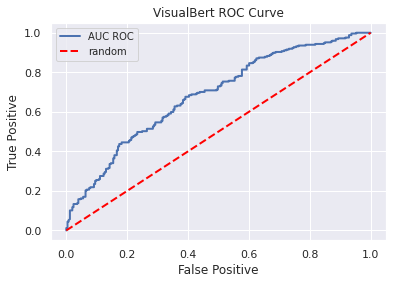

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, precision_recall_curve, plot_precision_recall_curve, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
fpr, tpr, thresholds1 = roc_curve(df_final['label'], df_final['proba'])
plt.figure(1)
plt.title("VisualBert ROC Curve")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.plot(fpr,tpr, linewidth=2, label="AUC ROC")
plt.plot([0,1],[0,1], linestyle="dashed", color="red", linewidth=2, label="random")
plt.legend(fontsize=10, loc="best")
plt.savefig('roc_vilbert.png')
plt.show()

In [7]:
roc_auc = np.trapz(tpr, fpr)
print("ROC AUC: ", roc_auc)

ROC AUC:  0.6831143684690595


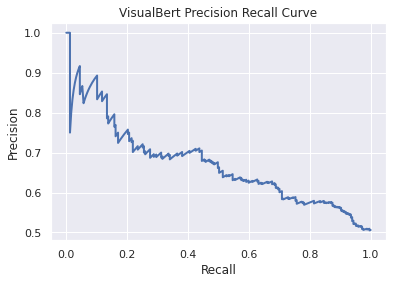

In [8]:
plt.figure(2)
plt.title("VisualBert Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
precision, recall, thresholds2 = precision_recall_curve(df_final['label'], df_final['proba'])
plt.plot(recall, precision, linewidth=2)
plt.show()

In [9]:
df_final.groupby("type")['id'].count()

type
FN    159
FP     39
TN    214
TP     88
Name: id, dtype: int64

In [10]:
# NEW WORK
import numpy as np
from PIL import Image
import csv
import json
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt 
import seaborn as sn
from sklearn.metrics import roc_auc_score
%matplotlib inline

In [11]:
# Ground Truth
valid = pd.read_json("/content/drive/MyDrive/hateful_meme/data/dev_seen.jsonl", lines=True)

In [12]:
valid.head()

,id,img,label,text
0,8291,img/08291.png,1,white people is this a shooting range
1,46971,img/46971.png,1,bravery at its finest
2,3745,img/03745.png,1,your order comes to $37.50 and your white priv...
3,83745,img/83745.png,1,it is time.. to send these parasites back to t...
4,80243,img/80243.png,1,mississippi wind chime


In [13]:
# Ground truth labels
actual = {valid['id'][i]:valid['label'][i] for i in range(500)}

In [14]:
valid.set_index("id", inplace=True)

In [15]:
# Helper Functions
'''
Returns True Positives, False Positives, True Negatives, False Negatives, AUROC_score
'''
def Statistics(actual, pred_labels, pred_prob, sorted_dict):
    
    #Correctly Predicted
    True_positives = defaultdict(int)
    True_negatives = defaultdict(int)


    #Benign Meme but predicted hateful
    False_positives = defaultdict(int)

    # Hateful Meme, but predicted Benign
    False_negatives = defaultdict(int)



    for ids in list(actual.keys()):

        if actual[ids] != pred_labels[ids]:

            if pred_prob[ids]>=0.5:
                False_positives[ids] = pred_prob[ids]

            else:
                 False_negatives[ids] = pred_prob[ids]   


        else:
            if pred_prob[ids]>=0.5:
                True_positives[ids] = pred_prob[ids]

            else:
                 True_negatives[ids] = pred_prob[ids]   
            
        
    return sorted_dict(True_positives), sorted_dict(True_negatives), sorted_dict(False_positives),  sorted_dict(False_negatives)
     

    

'''
Get count of True Positives, False Positives, True Negatives, False Negatives
'''
def count(True_positives, True_negatives, False_positives,  False_negatives):
    
    tp = len(True_positives)
    tn = len(True_negatives)
    fp = len(False_positives)
    fn = len(False_negatives)
    total = tp+tn+fp+fn
    
    return tp,tn,fp,fn,total




'''
Plots Confusion Matrix
'''
def plot_confusion_matrix(tn, fp, fn, tp, AUROC_score,total):
    
    
    matrix = np.array(([tn, fp],[fn,tp]))
    percent = (matrix/matrix.sum())*100
    
    accuracy = ((tp+tn)/total)*100
    Precision = (tp/(tp+fp))*100
    Recall = (tp/(tp+fn))*100
    F1_score =  2 * (Precision * Recall) / (Precision + Recall)
    
    
    df_cm = pd.DataFrame(matrix, ['Benign','Hateful'], ['Benign','Hateful'])
    text = np.asarray([['True Negatives', 'False Positives'], ['False Negatives', 'True Positives']])
    label = (np.asarray(["{0}\n\n{1}\n\n{2: .2f}%".format(text,matrix,percent) for text, matrix, percent in zip(text.flatten(), matrix.flatten(), percent.flatten())])).reshape(2,2)
    
    plt.figure(figsize=(10,10))
    sn.set(font_scale=2)
    sn.heatmap(df_cm, annot=label, annot_kws={"size": 20}, cbar_kws={'label':"Memes"}, fmt ='', cmap ='Blues')
    
    plt.title('Confusion Matrix', fontsize=20)
    plt.text(0.1, 2.5, 'Precision: '+str(round(Precision,2)) + '        Recall: '+str(round(Recall,2))+'     F1 Score: '+str(round(F1_score,2))+
            '\n\nAccuracy: '+ str(round(accuracy,2))+'          AUROC:'+ str(round(AUROC_score,2)), fontsize=20)
    plt.show()

    
    
    
'''
Get AUROC score using sklearn.metrics.roc_auc_score
'''
def get_AUROC(actual, pred_labels):
    
    ytrue=[]
    ypred=[]
    for ids in list(actual.keys()):
        ytrue.append(actual[ids])
        ypred.append(pred_labels[ids])

    AUROC_score = roc_auc_score(ytrue, ypred)
    
    return AUROC_score




'''
Return a Dictionary by it's values sorted in descending order
'''
def sorted_dict(unsorted_dictionary):
    sorted_keys = sorted(unsorted_dictionary, key =unsorted_dictionary.__getitem__, reverse=True)

    sorted_values = sorted(unsorted_dictionary.values(),reverse=True)

    sorted_dictionary = {}
    for i in range(len(sorted_keys)):
        sorted_dictionary[sorted_keys[i]] = sorted_values[i]
        
    return sorted_dictionary



'''
Display a Image
'''
def open_image(path, actual, pred_labels, pred_prob):
    label_dict = {0:'Benign', 1:'Hateful'}

    ground_truth = label_dict[actual[image_id]]
    predicted_label = label_dict[pred_labels[image_id]]
    confidence = pred_prob[image_id]
    
    image = Image.open('data/'+path)
    plt.figure(figsize=(10,10))
    plt.axis('off')
    plt.rcParams["axes.grid"] = False
    plt.text(0,image.size[1]+25, 'Annotated label: '+ ground_truth+ '       Predicted label: '+ predicted_label+ '       Probability: '+ str(round(confidence,4)), fontsize=15)
    plt.imshow(image)

In [16]:
#Analysis of Visual Bert on Validation set

#Predicted labels
%cd '/content/drive/MyDrive/hateful_meme/Baseline/VilBERT' 
predicted = pd.read_csv('hateful_memes_run_val__impaint_2021-12-04T15:18:12.csv')

/content/drive/MyDrive/hateful_meme/Baseline/VilBERT


In [17]:
predicted.head()

,id,proba,label
0,8291,1.762500e-05,0
1,46971,1.435715e-06,0
2,3745,7.024535e-07,0
3,83745,2.772138e-06,0
4,80243,8.347428e-01,1


In [18]:
# Predicted Labels
pred_labels = {predicted['id'][i]:predicted['label'][i] for i in range(500)}

In [19]:
# Predicted Probabilities
pred_prob = {predicted['id'][i]:predicted['proba'][i] for i in range(500)}

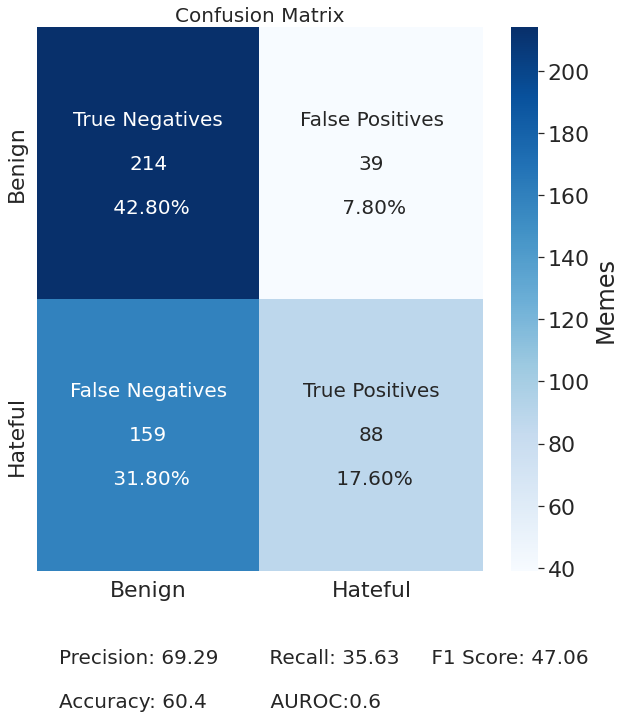

In [20]:
True_positives, True_negatives, False_positives,  False_negatives =  Statistics(actual, pred_labels, pred_prob, sorted_dict)

tp,tn,fp,fn,total = count(True_positives, True_negatives, False_positives,  False_negatives)

AUROC_score = get_AUROC(actual, pred_labels)

plot_confusion_matrix(tn, fp, fn, tp, AUROC_score, total)

/content/drive/MyDrive/hateful_meme


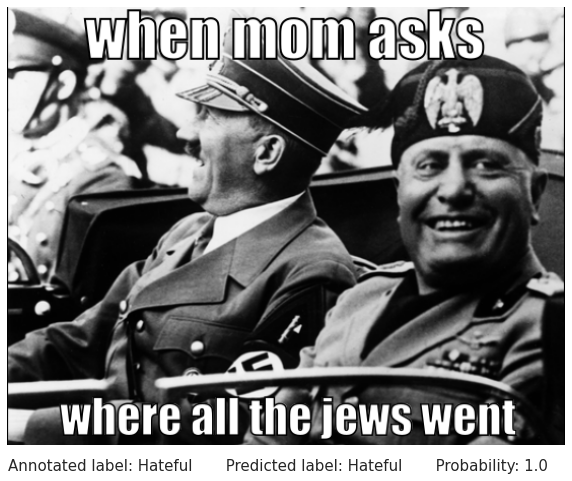

In [21]:
# True Positive with Highest Confidence (Hateful Meme predicted as Hateful)
# Change directory to the package folder
%cd '/content/drive/MyDrive/hateful_meme'

path = valid.loc[list(True_positives.keys())[0]]['img']
image_id = list(True_positives.keys())[0]
open_image(path, actual, pred_labels, pred_prob)

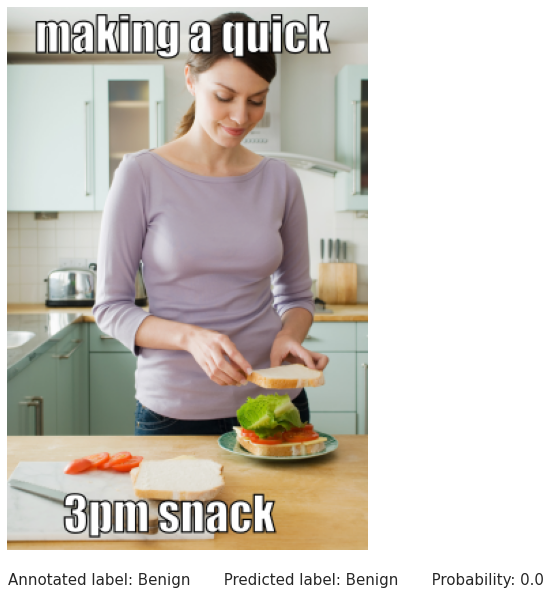

In [22]:
# True Negative with Highest Confidence (Benign meme predicted as Benign)
path = valid.loc[list(True_negatives.keys())[-3]]['img']
image_id = list(True_negatives.keys())[-3]

open_image(path, actual, pred_labels, pred_prob)

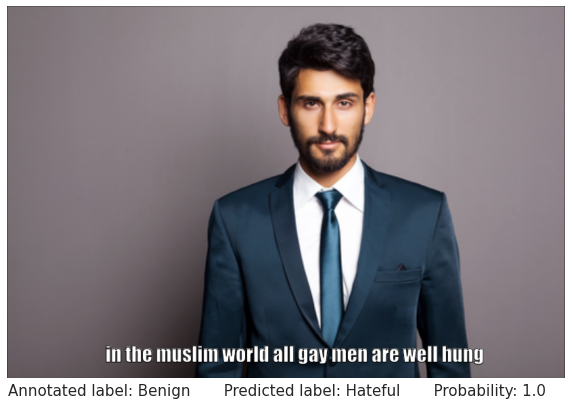

In [23]:
# False Positive with Highest Confidence (Benign meme prediced as Hateful)
path = valid.loc[list(False_positives.keys())[0]]['img']
image_id = list(False_positives.keys())[0]
open_image(path, actual, pred_labels, pred_prob)

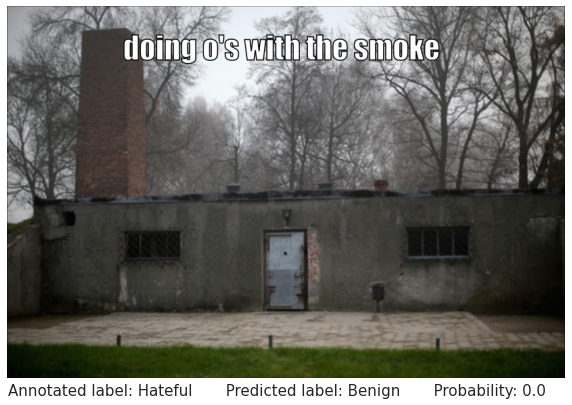

In [24]:
# False Negative with Highest Confidence (Hateful Meme predicted as Benign)
path = valid.loc[list(False_negatives.keys())[-1]]['img']
image_id = list(False_negatives.keys())[-1]
open_image(path, actual, pred_labels, pred_prob)